# L1 · Softmax, cross-entropy, and the gradient $p-y$

**One idea:** a classifier's categorical likelihood turns into cross-entropy
$\mathcal L=-\log p_{\text{true}}$, and the softmax+CE gradient collapses to the
beautifully simple $\nabla_z\mathcal L = p - y$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

def softmax(z):
    z = z - z.max()          # numerically stable
    e = np.exp(z)
    return e / e.sum()

## 1. Softmax: positive, sums to 1, shift-invariant
$\operatorname{softmax}(z) = \operatorname{softmax}(z + c\mathbf 1)$.

In [2]:
z = np.array([2.0, 1.0, 0.1])
p = softmax(z)
print("softmax(z) =", np.round(p, 4), " sum =", round(p.sum(), 6))
print("shift invariant:", np.allclose(softmax(z), softmax(z + 100)))

softmax(z) = [0.659  0.2424 0.0986]  sum = 1.0
shift invariant: True


## 2. Confident mistakes are expensive: $\ell = -\log p_{\text{true}}$
(reproducing the lecture numbers)

p_true = 0.9     ->  -log p_true = 0.105
p_true = 0.1     ->  -log p_true = 2.303
p_true = 0.001   ->  -log p_true = 6.908


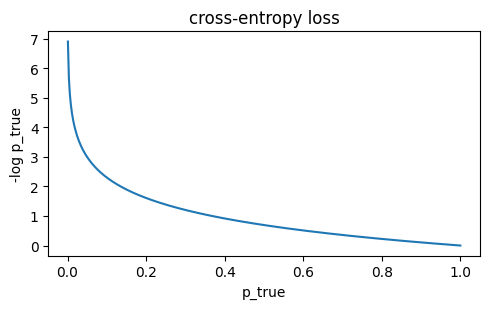

In [3]:
for p_y in [0.9, 0.1, 0.001]:
    print(f"p_true = {p_y:<6}  ->  -log p_true = {-np.log(p_y):.3f}")

grid = np.linspace(1e-3, 1.0, 400)
plt.figure(figsize=(5, 3.2))
plt.plot(grid, -np.log(grid))
plt.xlabel("p_true"); plt.ylabel("-log p_true"); plt.title("cross-entropy loss")
plt.tight_layout(); plt.show()

## 3. The gradient is just $p - y$
Verify analytic $\nabla_z\mathcal L = p - y$ against a finite-difference check.

In [4]:
z = np.array([2.0, 1.0, 0.1])
y = np.array([1.0, 0.0, 0.0])          # true class = 0 (one-hot)
analytic = softmax(z) - y

def loss(z):                            # L = -log p_true
    return -np.log(softmax(z)[0])

eps = 1e-6
numeric = np.zeros(3)
for k in range(3):
    zp = z.copy(); zp[k] += eps
    zm = z.copy(); zm[k] -= eps
    numeric[k] = (loss(zp) - loss(zm)) / (2*eps)

print("analytic  p - y :", np.round(analytic, 6))
print("numeric   dL/dz :", np.round(numeric, 6))
print("match:", np.allclose(analytic, numeric, atol=1e-5))

analytic  p - y : [-0.340999  0.242433  0.098566]
numeric   dL/dz : [-0.340999  0.242433  0.098566]
match: True


## Takeaway
- **Categorical likelihood $\Rightarrow$ cross-entropy** $=-\log p_{\text{true}}$.
- Always use the **stable softmax** (subtract the max) — it is shift-invariant.
- Softmax+CE has the clean gradient $\nabla_z\mathcal L = p - y$ (prediction minus target),
  which is why it previews backprop so nicely.